# 🎵 Playlist Communities
### Análise de Similaridade e Detecção de Comunidades em Playlists do Spotify

---

**Disciplina:** Processamento de Linguagem Natural  
**Curso:** Ciência de Dados — Fatec Baixada Santista - Rubens Lara  
**Autores:** Kauã Santana · Victor Leme

---

## Visão Geral

Toda playlist conta uma história — mas será que músicas colocadas juntas são realmente similares entre si? Este notebook investiga essa pergunta construindo dois **grafos de similaridade** sobre uma playlist do Spotify e identificando automaticamente agrupamentos (***comunidades***) de faixas que se parecem.

A análise é feita em duas perspectivas complementares:

- **Grafo Estrutural** — agrupa faixas por *duração* e *artista em comum*, capturando similaridade de formato e proximidade editorial
- **Grafo Lírico** — agrupa faixas pelo *conteúdo semântico das letras*, usando embeddings de linguagem para medir o quanto as músicas falam sobre os mesmos temas

Ao comparar as duas partições, é possível observar em que medida as escolhas editoriais de uma playlist refletem (ou divergem de) afinidades temáticas reais entre as músicas.

### Pipeline

```
Autenticação → Fetch Playlist → DataFrame → [Grafo Estrutural] → Comunidades
                                          → [Busca de Letras]  → [Grafo Lírico] → Comparação
```

### Métricas de Similaridade

**Grafo 1 — Duração + Artista**

$$\text{score}(i, j) = 0.7 \times \underbrace{\left(1 - |\hat{d}_i - \hat{d}_j|\right)}_{\text{duração normalizada}} + 0.3 \times \underbrace{\mathbb{1}[A_i \cap A_j \neq \emptyset]}_{\text{artista em comum}}$$

**Grafo 2 — Conteúdo Lírico**

$$\text{score}(i, j) = \cos(\vec{e}_i,\, \vec{e}_j) = \frac{\vec{e}_i \cdot \vec{e}_j}{\|\vec{e}_i\|\,\|\vec{e}_j\|}$$

Onde $\vec{e}$ é o embedding gerado pelo modelo multilíngue `paraphrase-multilingual-MiniLM-L12-v2`.

> **Nota metodológica:** A API do Spotify não retorna o campo `popularity` para apps em Development Mode a partir de novembro de 2024. A duração foi adotada como substituto — é um atributo contínuo e objetivo que captura similaridade de formato entre as faixas.

# Entendendo os Algoritmos de Similaridade Musical

Esta célula detalha as métricas utilizadas para calcular a proximidade entre músicas em uma playlist, explicando a lógica matemática por trás dos índices, variáveis e funções.

---

### 1. Os Índices $i$ e $j$
Representam dois elementos quaisquer de um conjunto (neste caso, duas músicas de uma playlist).
- Se a playlist tem 166 faixas, $i$ pode ser a música 1 e $j$ a música 2.
- O **score** calcula o nível de semelhança entre elas.
- O algoritmo processa todos os pares possíveis para montar uma **matriz de similaridade**.

---

### 2. Fórmula 1: Duração + Artista
Esta fórmula foca em metadados estruturais e de autoria.

$$\text{score}(i, j) = 0.7 \times (1 - |\hat{d}_i - \hat{d}_j|) + 0.3 \times \mathbb{1}[A_i \cap A_j \neq \emptyset]$$

#### Componentes da Fórmula:
* **Duração Normalizada ($\hat{d}$):** O "chapéu" indica que o valor foi normalizado para uma escala entre 0 e 1. Se a música mais curta tem 2 min e a mais longa 6 min, todas as durações são mapeadas proporcionalmente nesse intervalo.
* **Diferença Absoluta $| \hat{d}_i - \hat{d}_j |$:** Calcula a distância bruta entre as durações. Se forem iguais, o resultado é 0.
* **Inversão de Similaridade $1 - (\dots)$:** Transforma uma medida de "distância" em "proximidade". Quanto menor a diferença de tempo, mais o resultado se aproxima de 1.
* **Função Indicadora:** Vale **1** se a condição for verdadeira e **0** se for falsa. A condição verifica se a interseção dos conjuntos de artistas das músicas $i$ e $j$ não é vazia (ou seja, se compartilham pelo menos um artista).
* **Pesos (0.7 e 0.3):** Definem a importância de cada critério. A duração (contínua e discriminativa) representa 70% do score, enquanto o artista em comum (binário) representa 30%.

---

### 3. Fórmula 2: Conteúdo Lírico (Embeddings)
Esta fórmula utiliza Processamento de Linguagem Natural (NLP) para comparar o significado das letras.

$$\text{score}(i, j) = \cos(\vec{e}_i, \vec{e}_j) = \frac{\vec{e}_i \cdot \vec{e}_j}{\|\vec{e}_i\| \, \|\vec{e}_j\|}$$

#### Componentes da Fórmula:
* **Vetores de Significado ($\vec{e}_i, \vec{e}_j$):** São *embeddings* gerados pelo modelo `paraphrase-multilingual-MiniLM-L12-v2`. O modelo transforma a letra inteira em um vetor numérico de centenas de dimensões que codifica o contexto semântico.
* **Similaridade de Cosseno:** Mede o ângulo entre os vetores:
    * **Ângulo 0° (Cosseno 1):** Máxima similaridade.
    * **Ângulo 90° (Cosseno 0):** Sem relação semântica.
    * **Ângulo 180° (Cosseno -1):** Direções opostas.
* **Vantagem:** O cosseno ignora a magnitude (tamanho do vetor) e foca apenas na direção. Isso permite comparar uma letra longa com uma curta, desde que o tema seja o mesmo.
* **Numerador ($\vec{e}_i \cdot \vec{e}_j$):** Produto escalar que mede o alinhamento dos vetores.
* **Denominador $(\|\vec{e}_i\| \, \|\vec{e}_j\|)$:** Produto das normas (tamanhos). Dividir por isso é o que "limpa" a influência do tamanho do texto, isolando a direção do significado.

---

### Resumo Comparativo

| Métrica | Lógica Central |
| :--- | :--- |
| **Fórmula 1** | "Duas músicas são similares se durarem parecido e/ou forem do mesmo artista." |
| **Fórmula 2** | "Duas músicas são similares se as suas letras falarem sobre temas parecidos (medido pelo ângulo entre vetores)." |

---
## 0. Instalação de Dependências

As bibliotecas abaixo cobrem todas as etapas do pipeline: acesso à API do Spotify (`spotipy`), construção e análise de grafos (`python-igraph`, `cairocffi`), geração de embeddings de texto (`sentence-transformers`) e métricas de similaridade (`scikit-learn`).

In [ ]:
!pip install pandas numpy spotipy python-igraph cairocffi lyricsgenius sentence-transformers scikit-learn -q
print("✓ dependências instaladas")

✓ dependências instaladas


---
## 1. Imports

In [ ]:
import os
import time
import pandas as pd
import numpy as np
import igraph as ig
import spotipy
import lyricsgenius
from spotipy.oauth2 import SpotifyOAuth
from typing import List, Optional
from IPython.display import display, Image

print("✓ imports OK")

✓ imports OK


---
## 2. Credenciais

As credenciais são lidas via **Colab Secrets** (ícone 🔑 na barra lateral esquerda), sem expor valores no código. Para replicar este notebook, cadastre os seguintes segredos:

| Secret | Onde obter |
|---|---|
| `SPOTIFY_CLIENT_ID` | [Spotify Developer Dashboard](https://developer.spotify.com/dashboard) |
| `SPOTIFY_CLIENT_SECRET` | mesmo app |
| `GENIUS_TOKEN` | [Genius API Clients](https://genius.com/api-clients) |

In [ ]:
from google.colab import userdata

SPOTIFY_CLIENT_ID     = userdata.get('SPOTIFY_CLIENT_ID')
SPOTIFY_CLIENT_SECRET = userdata.get('SPOTIFY_CLIENT_SECRET')
GENIUS_TOKEN          = userdata.get('GENIUS_TOKEN')

print("✓ credenciais carregadas")

✓ credenciais carregadas


---
## 3. Autenticação

A autenticação usa **OAuth 2.0 com Authorization Code Flow** — obrigatório para leitura de playlists privadas e colaborativas via API do Spotify.

**Passo a passo:**
1. Execute a célula abaixo — ela imprimirá uma URL de autorização
2. Acesse a URL, faça login no Spotify e autorize o app
3. O navegador redirecionará para a página do Spotify (comportamento esperado)
4. Copie a URL completa da barra do navegador e cole no campo de entrada

In [ ]:
auth_manager = SpotifyOAuth(
    client_id=SPOTIFY_CLIENT_ID,
    client_secret=SPOTIFY_CLIENT_SECRET,
    redirect_uri='https://open.spotify.com',
    scope='playlist-read-private playlist-read-collaborative',
    open_browser=False,
)

print("Acesse a URL abaixo, autorize, e cole a URL completa pra qual foi redirecionado:\n")
print(auth_manager.get_authorize_url())
redirected_url = input("\nURL: ")

code = auth_manager.parse_response_code(redirected_url)
auth_manager.get_access_token(code)
sp = spotipy.Spotify(auth_manager=auth_manager)
print("✓ autenticado")

Acesse a URL abaixo, autorize, e cole a URL completa pra qual foi redirecionado:

https://accounts.spotify.com/authorize?client_id=b19112c9bb3e42d1a751346927fe6a6a&response_type=code&redirect_uri=https%3A%2F%2Fopen.spotify.com&scope=playlist-read-private+playlist-read-collaborative

URL: https://open.spotify.com/intl-pt/?code=AQB6MA633yIj0gK37vw6DdXrZlMU0EC8WKDxcY8pxn30LCkMjbDkzTvlvwSaw2ZNrx3pTo0EqSjOxwR0epleGAfMTBMG8h4QB68ZYNIyJle8bvP0Z0nWD7RwWWOHmluWUqmdrDif78rPA3BVL0dwKguVp3YBiy3cfMo7EU2OGDFVPWHgW6yMsNZTZ-UgCLBPrFczS9C_HiLTRAV14UTwc_lE-LsNpVwQiq1ZcI-vbkY
✓ autenticado


/tmp/ipykernel_1355/300381610.py:14: DeprecationWarning: You're using 'as_dict = True'.get_access_token will return the token string directly in future versions. Please adjust your code accordingly, or use get_cached_token instead.
  auth_manager.get_access_token(code)


---
## 4. Entrada e Fetch da Playlist

A função `fetch_playlist_tracks` usa **paginação automática** para contornar o limite de 50 itens por requisição da API do Spotify, garantindo que playlists longas sejam recuperadas integralmente.

**Formatos aceitos:**
- ID direto: `37i9dQZF1DXcBWIGoYBM5M`
- URI: `spotify:playlist:37i9dQZF1DXcBWIGoYBM5M`
- URL completa: `https://open.spotify.com/playlist/37i9dQZF1DXcBWIGoYBM5M`

> A playlist deve ser **pública** ou pertencer à conta autenticada.

In [ ]:
def fetch_playlist_tracks(sp: spotipy.Spotify, playlist_id: str) -> List[dict]:
    """Busca todas as tracks de uma playlist com paginação."""
    tracks, offset, limit = [], 0, 50
    print("Buscando tracks da playlist...")
    while True:
        results = sp.playlist_items(playlist_id, offset=offset, limit=limit)
        items = results.get('items', [])
        if not items:
            break
        for item in items:
            track = item.get('track') or item.get('item')
            if track and track.get('id'):
                tracks.append(track)
        if results.get('next') is None:
            break
        offset += limit
    print(f"✓ {len(tracks)} tracks encontradas")
    return tracks


playlist_id = input("Insira a playlist (ID, URI ou URL): ")
tracks = fetch_playlist_tracks(sp, playlist_id)

Insira a playlist (ID, URI ou URL): https://open.spotify.com/playlist/0cpqFZE5sB2wCXfIwLWzSr
Buscando tracks da playlist...
✓ 166 tracks encontradas


---
## 5. Estruturação do DataFrame

A partir dos objetos JSON retornados pela API, extraímos os atributos essenciais para a análise. O campo `popularity` está indisponível no modo Development desde novembro de 2024 e é preenchido com `0` — sua ausência motivou o uso da duração como métrica substituta no Grafo 1.

| Coluna | Descrição |
|---|---|
| `track_id` | Identificador único da faixa |
| `track_name` | Nome da faixa |
| `artist_id` | ID do artista principal |
| `artist_name` | Nome do artista principal |
| `duration_ms` | Duração em milissegundos |
| `popularity` | Índice de popularidade (indisponível — preenchido com 0) |
| `explicit` | Conteúdo explícito (booleano) |

In [ ]:
def build_dataframe(tracks: List[dict]) -> pd.DataFrame:
    """Consolida as tracks em um DataFrame estruturado."""
    data = []
    for track in tracks:
        if not isinstance(track, dict) or track.get('id') is None:
            continue
        artists = track.get('artists') or []
        artist  = artists[0] if artists else {}
        data.append({
            'track_id':    track.get('id'),
            'track_name':  track.get('name'),
            'artist_id':   artist.get('id'),
            'artist_name': artist.get('name'),
            'duration_ms': track.get('duration_ms', 0),
            'popularity':  track.get('popularity', 0),
            'explicit':    track.get('explicit', False),
        })
    df = pd.DataFrame(data)
    print(f"✓ DataFrame: {len(df)} tracks × {len(df.columns)} colunas")
    return df


def summarize_dataframe(df: pd.DataFrame) -> None:
    """Exibe resumo exploratório da playlist."""
    print(f"\n{'='*50}")
    print(f"  RESUMO DA PLAYLIST")
    print(f"{'='*50}")
    print(f"  Tracks:           {len(df)}")
    print(f"  Artistas únicos:  {df['artist_name'].nunique()}")
    print(f"  Duração total:    {df['duration_ms'].sum() / 60000:.1f} min")
    print(f"  Duração média:    {df['duration_ms'].mean() / 1000:.0f}s")
    print(f"  Explícitas:       {df['explicit'].sum()}")
    top = df['artist_name'].value_counts().head(5)
    print(f"\n  Top 5 artistas:")
    for artist, count in top.items():
        print(f"    • {artist}: {count} faixa(s)")
    print(f"{'='*50}\n")


df = build_dataframe(tracks)
summarize_dataframe(df)
display(df.head(10))

✓ DataFrame: 166 tracks × 7 colunas

  RESUMO DA PLAYLIST
  Tracks:           166
  Artistas únicos:  49
  Duração total:    558.4 min
  Duração média:    202s
  Explícitas:       78

  Top 5 artistas:
    • Kehlani: 18 faixa(s)
    • Kiana Ledé: 18 faixa(s)
    • SZA: 16 faixa(s)
    • Ella Mai: 15 faixa(s)
    • Carol Biazin: 10 faixa(s)



,track_id,track_name,artist_id,artist_name,duration_ms,popularity,explicit
0,6TrdeNEgbKuBqIToRfdWMY,Everybody Business,0cGUm45nv7Z6M6qdXYQGTX,Kehlani,165009,0,True
1,0Erf8mE7jAm6j94z48dxPx,I’m Her (feat. Kiana Ledé),3nViOFa3kZW8OMSNOzwr98,Queen Naija,198749,0,False
2,4jM3c9KLTO9iZPm9A7neiL,Love Language,0cGUm45nv7Z6M6qdXYQGTX,Kehlani,213364,0,False
3,1b0ZeVYPZCDaAk4pT42pxy,Chocolate. (ft. Ari Lennox),7jZMxhsB8djyIbYmoiJSTs,Kiana Ledé,186120,0,False
4,5oruuYKxGXcS0Cm1hpRLup,Cancelled.,7jZMxhsB8djyIbYmoiJSTs,Kiana Ledé,166626,0,True
5,0tkmYNfaEaH9HpR59ApRtE,Nunya (feat. Dom Kennedy),0cGUm45nv7Z6M6qdXYQGTX,Kehlani,244688,0,True
6,501mFwKeLnybf8JO3XL66O,altar,0cGUm45nv7Z6M6qdXYQGTX,Kehlani,243090,0,False
7,12LpEgxl7XLiuvv0PXj1DT,Pimenta,0mQoWD18BxzhN8kr1cNwgQ,Bivolt,164839,0,False
8,24QjawKdGJmsAIVe3EhzGH,F&MU,0cGUm45nv7Z6M6qdXYQGTX,Kehlani,134853,0,True
9,0s2SzCYqITp4lKdbxPQoYy,MULHER DO ANO XD,4PzYKhC14sTJNEr0dzoo0d,Luísa Sonza,155384,0,False


In [ ]:
os.makedirs('data', exist_ok=True)
df.to_csv('data/playlist_data.csv', index=False)
print("✓ dados salvos em 'data/playlist_data.csv'")

✓ dados salvos em 'data/playlist_data.csv'


---
## 6. Funções de Grafo

Esta seção define as funções utilitárias compartilhadas pelos dois pipelines. Elas são agnósticas à métrica de similaridade usada (não sabem e não precisam saber como a matriz de similaridade foi calculada.) — recebem uma matriz $N \times N$ e produzem grafo, comunidades e visualização de forma padronizada.

| Função | Responsabilidade |
|---|---|
| `extract_edges` | Filtra pares por threshold e limita vizinhos por nó |
| `create_graph` | Monta o grafo igraph com atributos de vértices e arestas |
| `detect_communities` | Aplica o algoritmo de Louvain para detecção de comunidades |
| `visualize_graph` | Renderiza o grafo como PNG com cores por comunidade |
| `print_communities` | Exibe artistas e duração média por comunidade |

In [ ]:
def extract_edges(
    df: pd.DataFrame,
    sim_matrix: np.ndarray,
    threshold: float = 0.6,
    max_per_node: int = 10
) -> pd.DataFrame:
    """
    Extrai arestas filtradas por threshold e limite de vizinhos.
    Cada nó mantém apenas suas max_per_node arestas de maior peso.
    """
    edges, n = [], len(df)
    print(f"Extraindo arestas (threshold={threshold}, max_per_node={max_per_node})...")
    for i in range(n):
        sims = sim_matrix[i].copy()
        sims[i] = -1
        for j in np.argsort(sims)[-max_per_node:]:
            if j > i and sims[j] >= threshold:
                edges.append({
                    'source':      df.iloc[i]['track_id'],
                    'source_name': df.iloc[i]['track_name'],
                    'target':      df.iloc[j]['track_id'],
                    'target_name': df.iloc[j]['track_name'],
                    'weight':      float(sims[j]),
                })
    edges_df = pd.DataFrame(edges)
    print(f"✓ {len(edges_df)} arestas extraídas")
    return edges_df


def create_graph(df: pd.DataFrame, edges_df: pd.DataFrame) -> ig.Graph:
    """Monta o grafo igraph com atributos de vértices e arestas."""
    track_to_idx = {tid: idx for idx, tid in enumerate(df['track_id'])}
    edge_list, weights = [], []
    for _, row in edges_df.iterrows():
        s = track_to_idx.get(row['source'])
        t = track_to_idx.get(row['target'])
        if s is not None and t is not None:
            edge_list.append((s, t))
            weights.append(row['weight'])
    g = ig.Graph(len(df), edges=edge_list, directed=False)
    g.vs['id']           = df['track_id'].tolist()
    g.vs['name']         = df['track_name'].tolist()
    g.vs['artist']       = df['artist_name'].tolist()
    g.vs['popularity']   = df['duration_ms'].tolist()  # armazena duração no campo popularity
    g.vs['_original_id'] = list(range(len(df)))
    g.vs['size']         = [15] * len(df)
    if weights:
        g.es['weight'] = weights
    print(f"✓ Grafo: {g.vcount()} nós | {g.ecount()} arestas")
    return g


def detect_communities(g: ig.Graph) -> list:
    """Detecta comunidades via Louvain (community_multilevel)."""
    if g.ecount() == 0:
        print("Grafo sem arestas — cada nó é sua própria comunidade.")
        g.vs['community'] = [0] * g.vcount()
        return [[i] for i in range(g.vcount())]
    print("Detectando comunidades (Louvain)...")
    weights   = 'weight' if 'weight' in g.es.attributes() else None
    partition = g.community_multilevel(weights=weights)
    g.vs['community'] = partition.membership
    communities = [partition.subgraph(i).vs['_original_id'] for i in range(len(partition))]
    print(f"✓ {len(communities)} comunidades detectadas")
    return communities


def visualize_graph(g: ig.Graph, filepath: str) -> None:
    """Renderiza e salva o grafo como PNG; exibe inline no Colab."""
    os.makedirs(os.path.dirname(filepath) or '.', exist_ok=True)
    layout  = g.layout_fruchterman_reingold(niter=500)
    palette = [
        '#FF3333', '#33FF57', '#3399FF', '#FF33F5', '#FFD700',
        '#FF8C00', '#00FFFF', '#FF69B4', '#7FFF00', '#9B59B6',
        '#00CED1', '#FF6347',
    ]
    g.vs['color'] = [
        palette[c % len(palette)] for c in g.vs['community']
    ] if 'community' in g.vs.attributes() else ['#4ECDC4'] * g.vcount()
    try:
        ig.plot(
            g, filepath,
            layout=layout,
            vertex_size=g.vs['size'],
            vertex_color=g.vs['color'],
            vertex_label=None,
            edge_width=[w * 2 for w in g.es['weight']] if 'weight' in g.es.attributes() else 1,
            edge_color='#CCCCCC',
            edge_arrow_size=0,
            margin=50,
        )
        print(f"✓ grafo salvo em '{filepath}'")
        display(Image(filepath, width=700))
    except Exception as e:
        print(f"⚠ erro ao renderizar: {e}")


def print_communities(graph: ig.Graph) -> None:
    """Exibe top artistas e duração média por comunidade."""
    membership = graph.vs['community']
    num_comms  = max(membership) + 1
    print(f"\n{'='*55}")
    for i in range(num_comms):
        artistas, duracoes = {}, []
        for idx, comm in enumerate(membership):
            if comm == i:
                a = graph.vs[idx]['artist']
                artistas[a] = artistas.get(a, 0) + 1
                duracoes.append(graph.vs[idx]['popularity'])  # popularity armazena duration_ms
        top   = sorted(artistas.items(), key=lambda x: x[1], reverse=True)[:5]
        total = sum(artistas.values())
        dur_media = np.mean(duracoes) / 1000
        print(f"\n  Comunidade {i} — {total} faixas | duração média: {dur_media:.0f}s")
        for artista, count in top:
            print(f"    • {artista}: {count} faixa(s)")
    print(f"\n{'='*55}")


print("✓ funções de grafo definidas")

✓ funções de grafo definidas


---
## 7. Grafo 1 — Similaridade por Duração + Artista

O primeiro grafo conecta faixas com base em características estruturais: **quanto tempo duram** e **se compartilham o mesmo artista**. A intuição é que músicas de formato similar tendem a ter o mesmo papel dentro de uma playlist.

### 7.1 Cálculo da Matriz de Similaridade

$$S_{ij} = 0.7 \times \left(1 - |\hat{d}_i - \hat{d}_j|\right) + 0.3 \times \mathbb{1}[A_i \cap A_j \neq \emptyset]$$

- $\hat{d}$ é a duração normalizada via min-max para $[0, 1]$
- O peso **70/30** reflete que a duração é contínua e discriminativa; o bônus por artista em comum captura agrupamentos editoriais naturais

In [ ]:
def compute_similarity_structural(df: pd.DataFrame) -> np.ndarray:
    """Calcula a matriz de similaridade N×N por duração e artista compartilhado."""
    n = len(df)
    sim = np.zeros((n, n))
    print(f"Calculando similaridade para {n} tracks...")
    dur_min, dur_max = df['duration_ms'].min(), df['duration_ms'].max()
    dur_norm = (df['duration_ms'] - dur_min) / (dur_max - dur_min) if dur_max > dur_min else np.ones(n) * 0.5
    for i in range(n):
        for j in range(i, n):
            if i == j:
                sim[i][j] = 1.0
            else:
                sim_dur = 1.0 - abs(float(dur_norm[i]) - float(dur_norm[j]))
                a_i = set(df.iloc[i]['artist_name'].split(', ')) if isinstance(df.iloc[i]['artist_name'], str) else set()
                a_j = set(df.iloc[j]['artist_name'].split(', ')) if isinstance(df.iloc[j]['artist_name'], str) else set()
                sim[i][j] = sim[j][i] = 0.7 * sim_dur + 0.3 * (1.0 if a_i & a_j else 0.0)
    print(f"✓ Matriz {n}×{n} computada")
    return sim


sim_structural = compute_similarity_structural(df)

mask = ~np.eye(len(df), dtype=bool)
vals = sim_structural[mask]
print(f"\nSimilaridade — mín: {vals.min():.3f} | média: {vals.mean():.3f} | máx: {vals.max():.3f}")

Calculando similaridade para 166 tracks...
✓ Matriz 166×166 computada

Similaridade — mín: 0.000 | média: 0.608 | máx: 1.000


### 7.2 Extração de Arestas, Grafo e Comunidades

Uma aresta é criada entre dois nós quando o score de similaridade supera o `THRESHOLD`. O parâmetro `MAX_PER_NODE` limita o grau máximo de cada vértice, evitando que nós muito centrais dominem a estrutura do grafo.

A detecção de comunidades usa o **algoritmo de Louvain** (`community_multilevel` no igraph), que maximiza a modularidade da partição de forma iterativa — um dos métodos mais eficientes e amplamente usados para grafos não direcionados com pesos.

**Legenda de cores do grafo:**

| Cor | Comunidade |
|---|---|
| 🔴 Vermelho `#FF3333` | Comunidade 0 |
| 🟢 Verde `#33FF57` | Comunidade 1 |
| 🔵 Azul `#3399FF` | Comunidade 2 |
| 🟣 Roxo `#FF33F5` | Comunidade 3 |
| 🟡 Amarelo `#FFD700` | Comunidade 4 |
| 🟠 Laranja `#FF8C00` | Comunidade 5 |
| 🩵 Ciano `#00FFFF` | Comunidade 6 |
| 🩷 Rosa `#FF69B4` | Comunidade 7 |

In [ ]:
THRESHOLD    = 0.6
MAX_PER_NODE = 10

edges_structural = extract_edges(df, sim_structural, threshold=THRESHOLD, max_per_node=MAX_PER_NODE)
edges_structural.to_csv('data/edges_structural.csv', index=False)

graph_structural = create_graph(df, edges_structural)
communities_structural = detect_communities(graph_structural)
print(f"Tamanho das comunidades: {sorted([len(c) for c in communities_structural], reverse=True)}")

Extraindo arestas (threshold=0.6, max_per_node=10)...
✓ 809 arestas extraídas
✓ Grafo: 166 nós | 809 arestas
Detectando comunidades (Louvain)...
✓ 8 comunidades detectadas
Tamanho das comunidades: [26, 26, 23, 20, 20, 19, 16, 16]


In [ ]:
print_communities(graph_structural)



  Comunidade 0 — 20 faixas | duração média: 212s
    • Kehlani: 18 faixa(s)
    • Jacquees: 1 faixa(s)
    • Daniel Caesar: 1 faixa(s)

  Comunidade 1 — 23 faixas | duração média: 209s
    • Ella Mai: 14 faixa(s)
    • H.E.R.: 2 faixa(s)
    • Queen Naija: 1 faixa(s)
    • Khalid: 1 faixa(s)
    • Justin Bieber: 1 faixa(s)

  Comunidade 2 — 20 faixas | duração média: 168s
    • Kiana Ledé: 17 faixa(s)
    • Kelly Rowland: 1 faixa(s)
    • LUDMILLA: 1 faixa(s)
    • FLO: 1 faixa(s)

  Comunidade 3 — 19 faixas | duração média: 163s
    • Carol Biazin: 10 faixa(s)
    • KAROL G: 2 faixa(s)
    • Bivolt: 1 faixa(s)
    • Luísa Sonza: 1 faixa(s)
    • H.E.R.: 1 faixa(s)

  Comunidade 4 — 16 faixas | duração média: 174s
    • Summer Walker: 6 faixa(s)
    • V: 5 faixa(s)
    • Gloria Groove: 1 faixa(s)
    • Vitão: 1 faixa(s)
    • FLO: 1 faixa(s)

  Comunidade 5 — 26 faixas | duração média: 201s
    • Colette Lush: 6 faixa(s)
    • Sabrina Carpenter: 4 faixa(s)
    • IZA: 3 faixa(s)
    •

✓ grafo salvo em 'graphs/graph_structural.png'


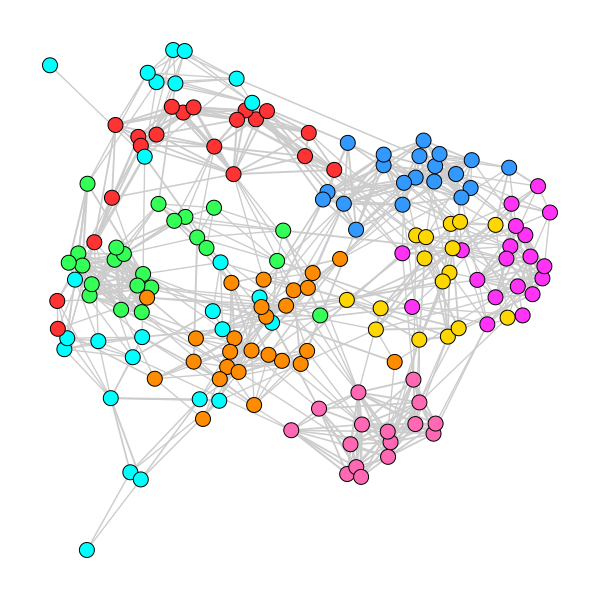

✓ GraphML salvo em 'graphs/graph_structural.graphml'


In [ ]:
os.makedirs('graphs', exist_ok=True)
visualize_graph(graph_structural, 'graphs/graph_structural.png')
graph_structural.write_graphml('graphs/graph_structural.graphml')
print("✓ GraphML salvo em 'graphs/graph_structural.graphml'")

### Interpretação — Grafo Estrutural

O grafo resultante possui **166 nós** e **809 arestas**, com o algoritmo de Louvain detectando **8 comunidades** de tamanhos equilibrados (entre 16 e 26 faixas cada).

A estrutura revela que a playlist é **dominada por artistas com discografias coesas em termos de duração**: as comunidades 0 e 7 são praticamente monográficas — a comunidade 0 concentra 18 das 20 faixas de Kehlani, e a comunidade 7 reúne todas as 16 faixas de SZA presentes na playlist. Isso indica que ambas as artistas têm um formato característico de faixa que as diferencia das demais.

As comunidades 1 (Ella Mai, 14 faixas) e 2 (Kiana Ledé, 17 faixas) seguem o mesmo padrão. Já as comunidades 5 e 6 são mais heterogêneas, reunindo artistas variados que compartilham faixas de duração semelhante — a comunidade 6, por exemplo, agrupa artistas de faixas longas (duração média de **261s**, a maior do grafo), como Liniker, Beyoncé e Ari Lennox.

> **O que isso significa?** A métrica estrutural captura bem a identidade sonora de formato de cada artista, mas não diz nada sobre o que as letras falam. A próxima seção investiga essa dimensão.

---
## 8. Grafo 2 — Similaridade por Conteúdo Lírico

O segundo grafo conecta faixas pelo **significado das letras**. Diferente do grafo estrutural, que opera sobre números, este pipeline precisa transformar texto em vetores comparáveis — tarefa que exige um modelo de linguagem.

### 8.1 Carregamento das Letras

As letras foram coletadas externamente via **Genius** (fonte primária) e **LRCLib** (fallback), por meio do script `fetch_lyrics.py`. O Genius bloqueia requisições oriundas de IPs de datacenter como os do Google Colab, tornando necessária a coleta local e o upload do CSV resultante.

O `lyrics_map` abaixo reconstrói o dicionário `{track_id → letra}` a partir dos arquivos gerados, mantendo compatibilidade com o restante do pipeline.

In [ ]:
# ── 8.1 Carregamento das letras (CSV gerado localmente) ───────────────────────
import pandas as pd

df_lyrics_raw = pd.read_csv('data/lyrics.csv')
lyrics_report = pd.read_csv('data/lyrics_report.csv')

# Reconstrói o lyrics_map no mesmo formato esperado pelas células seguintes
# {track_id -> letra (str) | None}
lyrics_map = {}

# Faixas com letra
for _, row in df_lyrics_raw.iterrows():
    lyrics_map[row['track_id']] = row['lyrics']

# Faixas sem letra (estão só no report) recebem None
for _, row in lyrics_report[lyrics_report['status'] == 'failed'].iterrows():
    lyrics_map[row['track_id']] = None

# Resumo
ok     = (lyrics_report['status'] == 'ok').sum()
failed = (lyrics_report['status'] == 'failed').sum()
total  = len(lyrics_report)

print(f"✓ {ok}/{total} letras carregadas ({failed} sem letra)")
if failed > 0:
    print(f"\nFaixas excluídas do grafo lírico:")
    sem = lyrics_report[lyrics_report['status'] == 'failed'][['track_name', 'artist_name', 'fail_reason']]
    display(sem.reset_index(drop=True))

print("\n✓ lyrics_map pronto")

✓ 166/166 letras carregadas (0 sem letra)

✓ lyrics_map pronto


### 8.2 Embeddings e Similaridade de Cosseno

O modelo escolhido é o **`paraphrase-multilingual-MiniLM-L12-v2`**, disponível via Sentence Transformers. A escolha é justificada por três critérios:

1. **Multilíngue nativo** — suporta 50+ idiomas sem pré-processamento específico por língua, essencial para uma playlist com músicas em inglês e português
2. **Semântico** — captura significado, não apenas frequência de palavras; músicas sobre o mesmo tema ficam próximas mesmo com vocabulário diferente
3. **Leve e eficiente** — ~120 MB, roda em CPU no Colab sem necessidade de GPU

A alternativa TF-IDF foi descartada por exigir pré-processamento por idioma (stopwords, stemming) e por não capturar semântica — duas músicas sobre "saudade" com vocabulários diferentes seriam consideradas distantes.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


def compute_similarity_lyric(df: pd.DataFrame, lyrics_map: dict) -> tuple:
    """
    Calcula matriz de similaridade de cosseno entre letras via embeddings.
    Faixas sem letra são excluídas e documentadas.

    returns:
        sim_matrix: np.ndarray N'×N'
        df_valid:   DataFrame apenas das faixas com letra (mesma ordem)
    """
    df_valid  = df[df['track_id'].map(lambda tid: lyrics_map.get(tid) is not None)].copy().reset_index(drop=True)
    valid_ids = df_valid['track_id'].tolist()
    letras    = [lyrics_map[tid] for tid in valid_ids]
    n = len(valid_ids)

    if n == 0:
        print("⚠ Nenhuma letra disponível — grafo lírico não pode ser construído.")
        return np.array([]), df_valid

    print(f"Gerando embeddings para {n} faixas...")
    print("  (primeira execução faz download do modelo ~120MB)")

    model      = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    embeddings = model.encode(letras, show_progress_bar=True, batch_size=16)
    sim_matrix = cosine_similarity(embeddings).astype(np.float32)
    np.fill_diagonal(sim_matrix, 1.0)

    print(f"\n✓ Matriz {n}×{n} computada")
    mask = ~np.eye(n, dtype=bool)
    vals = sim_matrix[mask]
    print(f"  Similaridade — mín: {vals.min():.3f} | média: {vals.mean():.3f} | máx: {vals.max():.3f}")

    return sim_matrix, df_valid


sim_lyric, df_lyric = compute_similarity_lyric(df, lyrics_map)

Gerando embeddings para 166 faixas...
  (primeira execução faz download do modelo ~120MB)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]


✓ Matriz 166×166 computada
  Similaridade — mín: -0.001 | média: 0.449 | máx: 1.000


### 8.3 Extração de Arestas, Grafo e Comunidades

O threshold para o grafo lírico (`0.5`) é menor que o estrutural (`0.6`) porque a similaridade de cosseno entre embeddings de texto tende a produzir scores mais baixos — a distribuição de valores é mais dispersa quando comparamos semântica de letras inteiras.

**Legenda de cores do grafo:**

| Cor | Comunidade |
|---|---|
| 🔴 Vermelho `#FF3333` | Comunidade 0 |
| 🟢 Verde `#33FF57` | Comunidade 1 |
| 🔵 Azul `#3399FF` | Comunidade 2 |
| 🟣 Roxo `#FF33F5` | Comunidade 3 |
| 🟡 Amarelo `#FFD700` | Comunidade 4 |
| 🟠 Laranja `#FF8C00` | Comunidade 5 |
| 🩵 Ciano `#00FFFF` | Comunidade 6 |
| 🩷 Rosa `#FF69B4` | Comunidade 7 |
| 🟩 Verde-limão `#7FFF00` | Comunidade 8 |
| 🟪 Lilás `#9B59B6` | Comunidade 9 |
| 🩴 Turquesa `#00CED1` | Comunidade 10 |
| 🍅 Tomate `#FF6347` | Comunidade 11 |
| *(sem cor distinta)* | Comunidade 12 |

In [ ]:
THRESHOLD_LYRIC = 0.5  # threshold menor — embeddings de cosseno tendem a scores mais baixos

edges_lyric = extract_edges(df_lyric, sim_lyric, threshold=THRESHOLD_LYRIC, max_per_node=MAX_PER_NODE)
edges_lyric.to_csv('data/edges_lyric.csv', index=False)

graph_lyric = create_graph(df_lyric, edges_lyric)
communities_lyric = detect_communities(graph_lyric)
print(f"Tamanho das comunidades: {sorted([len(c) for c in communities_lyric], reverse=True)}")

Extraindo arestas (threshold=0.5, max_per_node=10)...
✓ 762 arestas extraídas
✓ Grafo: 166 nós | 762 arestas
Detectando comunidades (Louvain)...
✓ 13 comunidades detectadas
Tamanho das comunidades: [45, 28, 27, 19, 16, 14, 6, 6, 1, 1, 1, 1, 1]


In [ ]:
print_communities(graph_lyric)



  Comunidade 0 — 27 faixas | duração média: 196s
    • Kehlani: 5 faixa(s)
    • Ella Mai: 5 faixa(s)
    • Kiana Ledé: 4 faixa(s)
    • Sabrina Carpenter: 3 faixa(s)
    • Beyoncé: 2 faixa(s)

  Comunidade 1 — 45 faixas | duração média: 203s
    • Carol Biazin: 5 faixa(s)
    • Liniker: 4 faixa(s)
    • Kiana Ledé: 3 faixa(s)
    • IZA: 3 faixa(s)
    • Kehlani: 2 faixa(s)

  Comunidade 2 — 14 faixas | duração média: 224s
    • Kehlani: 4 faixa(s)
    • Summer Walker: 2 faixa(s)
    • SZA: 2 faixa(s)
    • GIVĒON: 1 faixa(s)
    • Bela Maria: 1 faixa(s)

  Comunidade 3 — 28 faixas | duração média: 189s
    • Kiana Ledé: 7 faixa(s)
    • Kehlani: 4 faixa(s)
    • Ari Lennox: 2 faixa(s)
    • SZA: 2 faixa(s)
    • Megan Thee Stallion: 2 faixa(s)

  Comunidade 4 — 6 faixas | duração média: 194s
    • Summer Walker: 2 faixa(s)
    • Kiana Ledé: 1 faixa(s)
    • Babyface: 1 faixa(s)
    • Zedd: 1 faixa(s)
    • Kehlani: 1 faixa(s)

  Comunidade 5 — 19 faixas | duração média: 206s
    • S

✓ grafo salvo em 'graphs/graph_lyric.png'


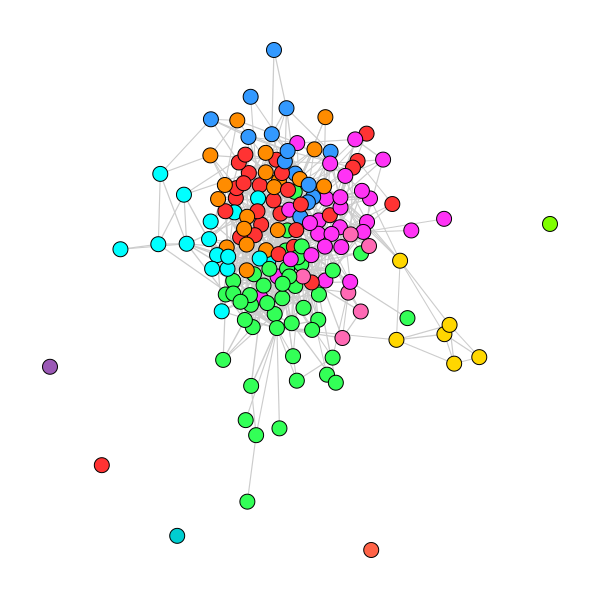

✓ GraphML salvo em 'graphs/graph_lyric.graphml'


In [ ]:
visualize_graph(graph_lyric, 'graphs/graph_lyric.png')
graph_lyric.write_graphml('graphs/graph_lyric.graphml')
print("✓ GraphML salvo em 'graphs/graph_lyric.graphml'")

### Interpretação — Grafo Lírico

O grafo lírico possui as mesmas **166 faixas**, mas uma estrutura bem diferente: **762 arestas** e **13 comunidades**, com distribuição muito mais desigual (a maior tem 45 faixas; 5 comunidades têm apenas 1 faixa cada).

A fragmentação maior revela que, **liricamente, a playlist é mais heterogênea do que estruturalmente**. As 5 faixas isoladas (comunidades 8–12) são casos extremos: letras sem paralelo semântico suficiente com nenhuma outra faixa para superar o threshold de 0.5 — um dado metodológico relevante, não uma falha.

O padrão mais notável é a **dissolução dos clusters por artista**: enquanto no grafo estrutural Kehlani e SZA formavam comunidades quase exclusivas, no grafo lírico suas faixas se dispersam por 4–5 comunidades distintas. Isso indica que, embora essas artistas tenham um *formato* característico, seu repertório abrange **temas líricos variados**.

A comunidade 1 (45 faixas, a maior) mistura Carol Biazin, Liniker, Kiana Ledé e IZA — artistas de origens bem distintas —, sugerindo convergência temática que a análise estrutural jamais revelaria.

---
## 9. Comparação entre os Grafos

Com os dois grafos construídos, é possível confrontar as duas perspectivas de similaridade diretamente. A tabela abaixo resume as métricas estruturais de cada grafo.

In [ ]:
def graph_metrics(g: ig.Graph, label: str) -> dict:
    comms = max(g.vs['community']) + 1 if 'community' in g.vs.attributes() else None
    return {
        'grafo':        label,
        'nós':          g.vcount(),
        'arestas':      g.ecount(),
        'densidade':    round(g.density(), 4),
        'grau médio':   round(np.mean(g.degree()), 2),
        'comunidades':  comms,
    }


comp = pd.DataFrame([
    graph_metrics(graph_structural, 'Duração + Artista'),
    graph_metrics(graph_lyric,      'Conteúdo Lírico'),
]).set_index('grafo')

display(comp)

,nós,arestas,densidade,grau médio,comunidades
grafo,,,,,
Duração + Artista,166,809,0.0591,9.75,8
Conteúdo Lírico,166,762,0.0556,9.18,13


### Interpretação — O que os números dizem

| Métrica | Grafo Estrutural | Grafo Lírico | Interpretação |
|---|---|---|---|
| Arestas | 809 | 762 | O grafo estrutural é levemente mais denso |
| Densidade | 0.0591 | 0.0556 | Ambos são grafos esparsos — esperado |
| Grau médio | 9.75 | 9.18 | Cada faixa tem ~9 vizinhos em média |
| **Comunidades** | **8** | **13** | Diferença central do trabalho |

A diferença mais significativa está no **número de comunidades**: 8 vs 13. Isso tem uma interpretação direta — a métrica estrutural agrupa faixas de forma mais coesa e com grupos maiores, enquanto a métrica lírica fragmenta mais, encontrando nichos semânticos que a duração não captura.

**O que isso revela sobre a playlist?**

A playlist analisada foi montada com critério artístico/editorial — as faixas de uma mesma artista foram adicionadas em bloco, o que explica a alta coesão estrutural (8 comunidades bem definidas por artista). Já a análise lírica desfaz essa organização e revela que o repertório é tematicamente diverso: músicas da mesma artista falam sobre coisas diferentes, e músicas de artistas distintas convergem para os mesmos temas.

Em outras palavras: **a playlist é editorialmente coesa, mas liricamente rica e variada** — o que pode ser exatamente o que a torna interessante.

---
## 10. Conclusão

Este notebook demonstrou que **métricas de similaridade diferentes revelam estruturas de comunidade diferentes** — uma das questões centrais do campo de detecção de comunidades em grafos.

Partindo de uma playlist real do Spotify com 166 faixas e 49 artistas:

- O **Grafo Estrutural** (duração + artista) produziu **8 comunidades** equilibradas, fortemente influenciadas pela identidade de formato de cada artista. Artistas com repertório característico — como SZA e Kehlani — formaram clusters quase exclusivos.

- O **Grafo Lírico** (embeddings de letras) produziu **13 comunidades** com distribuição mais assimétrica, capturando nichos semânticos que transcendem a identidade artística. Artistas distintas convergiram tematicamente; artistas prolíficas se dispersaram por múltiplos clusters.

A comparação entre as duas partições evidencia que **formato e conteúdo são dimensões complementares, não redundantes** da similaridade musical. Uma análise completa de playlists se beneficiaria de combinar ambas — e é exatamente isso que abordagens multimodais em PLN buscam fazer.

### Limitações e trabalhos futuros

- A métrica estrutural é simples por design; atributos como BPM, tonalidade e energia (disponíveis via Spotify Audio Features em contas comerciais) enriqueceriam o Grafo 1
- O Louvain é não-determinístico; execuções repetidas podem gerar partições ligeiramente diferentes
- A análise lírica atual usa a letra inteira como documento; segmentar por seção (verso, refrão) poderia revelar estrutura semântica mais fina
- A comparação quantitativa entre partições (NMI, ARI) é um passo natural para formalizar a divergência observada

In [ ]:
print("="*55)
print("  PIPELINE CONCLUÍDO")
print("="*55)
print("\nArquivos gerados:")
for f in [
    'data/playlist_data.csv',
    'data/lyrics_report.csv',
    'data/edges_structural.csv',
    'data/edges_lyric.csv',
    'graphs/graph_structural.png',
    'graphs/graph_structural.graphml',
    'graphs/graph_lyric.png',
    'graphs/graph_lyric.graphml',
]:
    existe = "✓" if os.path.exists(f) else "✗"
    print(f"  {existe} {f}")
print("="*55)

  PIPELINE CONCLUÍDO

Arquivos gerados:
  ✓ data/playlist_data.csv
  ✓ data/lyrics_report.csv
  ✓ data/edges_structural.csv
  ✓ data/edges_lyric.csv
  ✓ graphs/graph_structural.png
  ✓ graphs/graph_structural.graphml
  ✓ graphs/graph_lyric.png
  ✓ graphs/graph_lyric.graphml


---
## Referências

- Blondel, V. D. et al. (2008). *Fast unfolding of communities in large networks*. Journal of Statistical Mechanics: Theory and Experiment.
- Fruchterman, T. M. J. & Reingold, E. M. (1991). *Graph drawing by force-directed placement*. Software: Practice and Experience, 21(11).
- Reimers, N. & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks*. Proceedings of EMNLP.
- [Spotify Web API Reference](https://developer.spotify.com/documentation/web-api)
- [python-igraph Documentation](https://python.igraph.org/en/stable/)
- [Sentence Transformers](https://www.sbert.net/)
- [LyricsGenius](https://lyricsgenius.readthedocs.io/)
- [LRCLib](https://lrclib.net/)